# Unified Poisson Solver Testing
This notebook runs the unified test suites for Problem 1 (Table 1 & 2) as well as the complete NUDFT/NUFFT Accuracy Comparisons, tracking strictly $L_2$ relative errors and computational runtimes.

In [1]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup & Configurable Parameters
Configure domain radius, solver tolerances, Tikhonov regularization $\lambda$, equations/problems, and grid sweep resolutions.

In [2]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)

# =============================================================================
# Grid Sweep Resolutions
# =============================================================================
N_vals_p0 = [32, 64, 128, 256, 512]
M_vals_p0 = [32, 64, 128, 256, 512]
N_fixed_p0 = 32

N_vals_p1 = [32, 64, 128, 256, 512]
M_vals_p1 = [32, 64, 128, 256, 512]
N_fixed_p1 = 32

N_vals_p2 = [32, 64, 128, 256, 512]
M_vals_p2 = [32, 64, 128, 256, 512]
N_fixed_p2 = 32

N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]

MUTE_OUTPUT = True


# Run Problems

In [3]:
# -----------------------------------------------------------------------------
# Methods for Problem 2 Single-Grid Tables (Using Pure Random Grid as the example)
# -----------------------------------------------------------------------------
METHODS_P2 = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-random-NUDFT", label="Fixed random / NUDFT", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, use_nudft=True),
    # Explicitly specify grid_type=2 for Toeplitz
    dict(name="Fixed-random-NUFFT-Toeplitz", label="Fixed random / NUFFT (Toeplitz)", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, grid_type=2, use_nudft=False),
    # Explicitly specify grid_type=3 for Unsquared PCGLS
    dict(name="Fixed-random-NUFFT-Unsquared", label="Fixed random / NUFFT (Unsquared)", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, grid_type=3, use_nudft=False),
]

# -----------------------------------------------------------------------------
# Methods for the Full Accuracy Comparison Sweep
# -----------------------------------------------------------------------------
METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]

# Include rand, sine, and clustered here:
for kind in ("rand", "sine", "clustered"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        # Explicitly specify grid_type=2 for Toeplitz
        dict(name=f"Fixed-{kind}-NUFFT-Toeplitz", label=f"Fixed {kind} / NUFFT (Toeplitz)", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, grid_type=2, use_nudft=False),
        # Explicitly specify grid_type=3 for Unsquared PCGLS
        dict(name=f"Fixed-{kind}-NUFFT-Unsquared", label=f"Fixed {kind} / NUFFT (Unsquared)", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, grid_type=3, use_nudft=False),
    ]


print("\nRunning Problem 2 - Table 1 (Random Grid)...")
df_p2_t1 = run_tests_pipeline(N_vals_p2, M_vals_p2, fixed_other=None, methods=METHODS_P2, test_type="P1_Table1", mute=MUTE_OUTPUT)
print("\nRunning Problem 2 - Table 2 (Random Grid)...")
df_p2_t2 = run_tests_pipeline(None, M_vals_p2, fixed_other=N_fixed_p2, methods=METHODS_P2, test_type="P1_Table2", mute=MUTE_OUTPUT)

print("\nRunning Accuracy Comparisons...")
df_cN = run_tests_pipeline(N_vals_c, None, fixed_other=32, methods=METHODS_COMP, test_type="Accuracy_VaryN", mute=MUTE_OUTPUT)
df_cM = run_tests_pipeline(None, M_vals_c, fixed_other=32, methods=METHODS_COMP, test_type="Accuracy_VaryM", mute=MUTE_OUTPUT)
print("Done.")



Running Problem 2 - Table 1 (Random Grid)...


Pipeline (P1_Table1): 100%|██████████| 4/4 [01:25<00:00, 21.29s/it, method=Fixed-random-NUFFT-Unsquared]



Running Problem 2 - Table 2 (Random Grid)...


Pipeline (P1_Table2): 100%|██████████| 4/4 [00:26<00:00,  6.71s/it, method=Fixed-random-NUFFT-Unsquared]



Running Accuracy Comparisons...


Pipeline (Accuracy_VaryM): 100%|██████████| 12/12 [00:19<00:00,  1.60s/it, method=Fixed-clustered-NUFFT-Unsquared]

Done.


# Accuracy

--- ACCURACY SECTION ---
Problem 2 - Table 1 - errors should be the same for rows, and decrease along columns. uniform, nudft, and nufft should be same

Problem 2 - Table 1 Accuracy


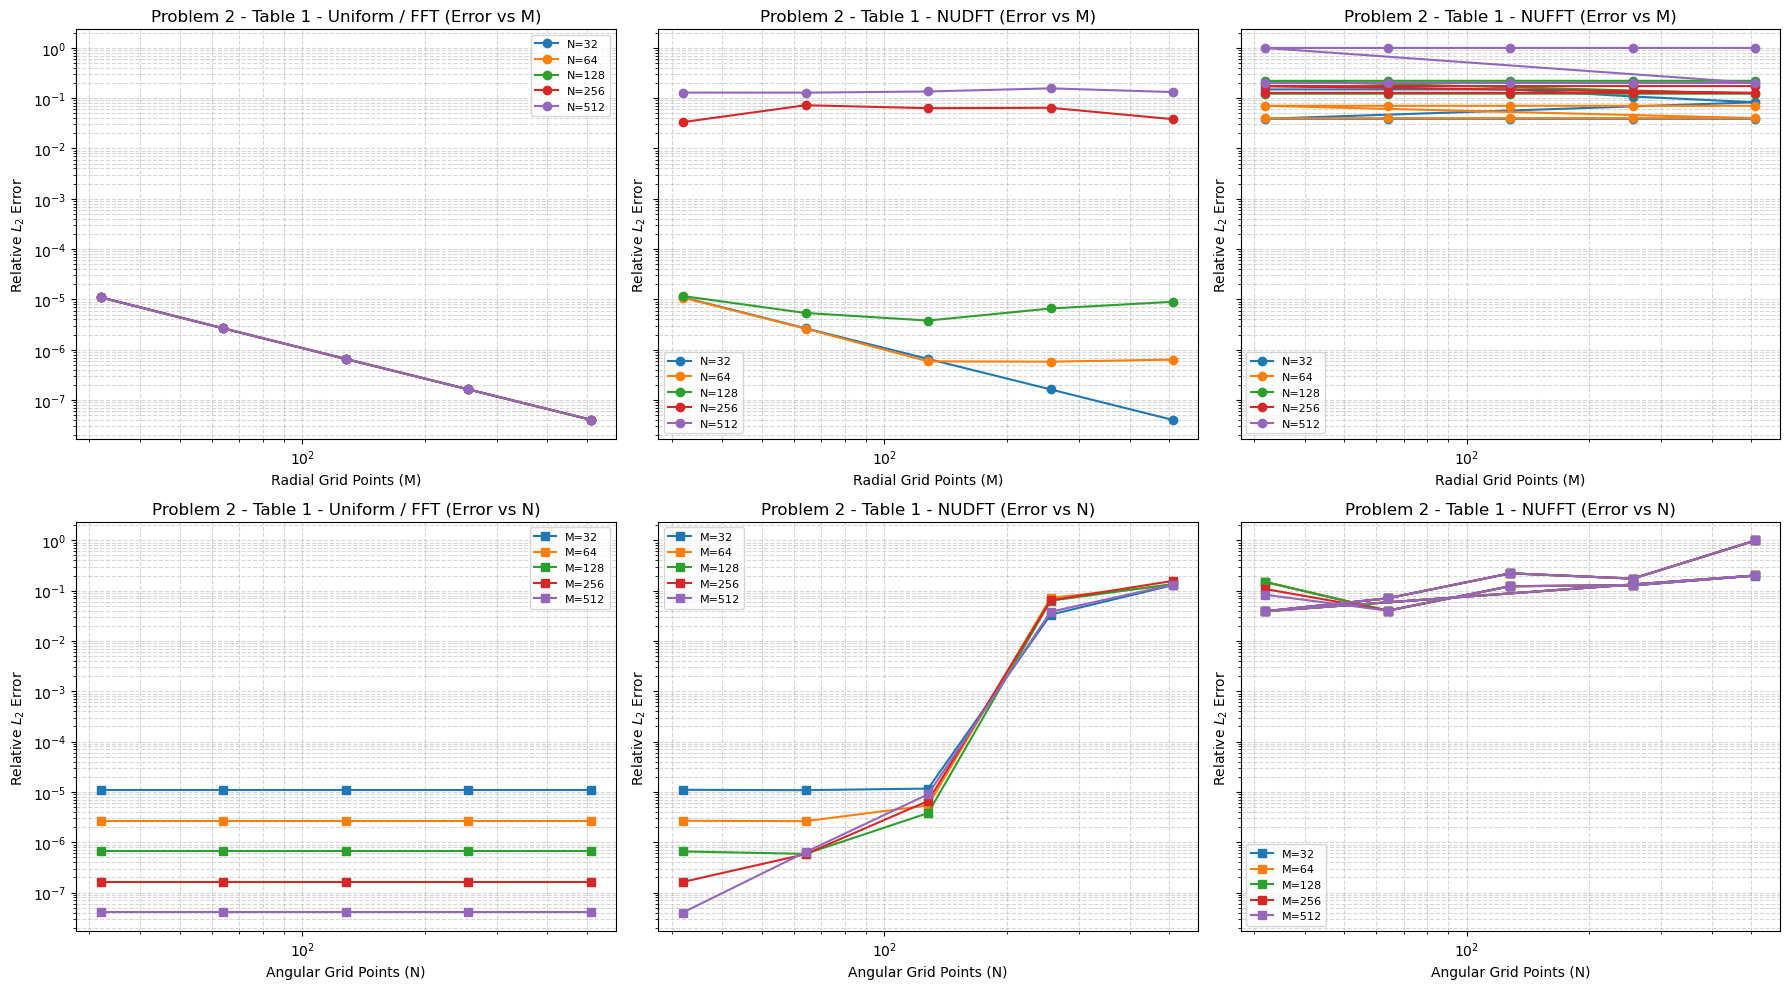

Problem 2 - Table 2 - errors should decrease along rows

Problem 2 - Table 2 (N=32) Accuracy


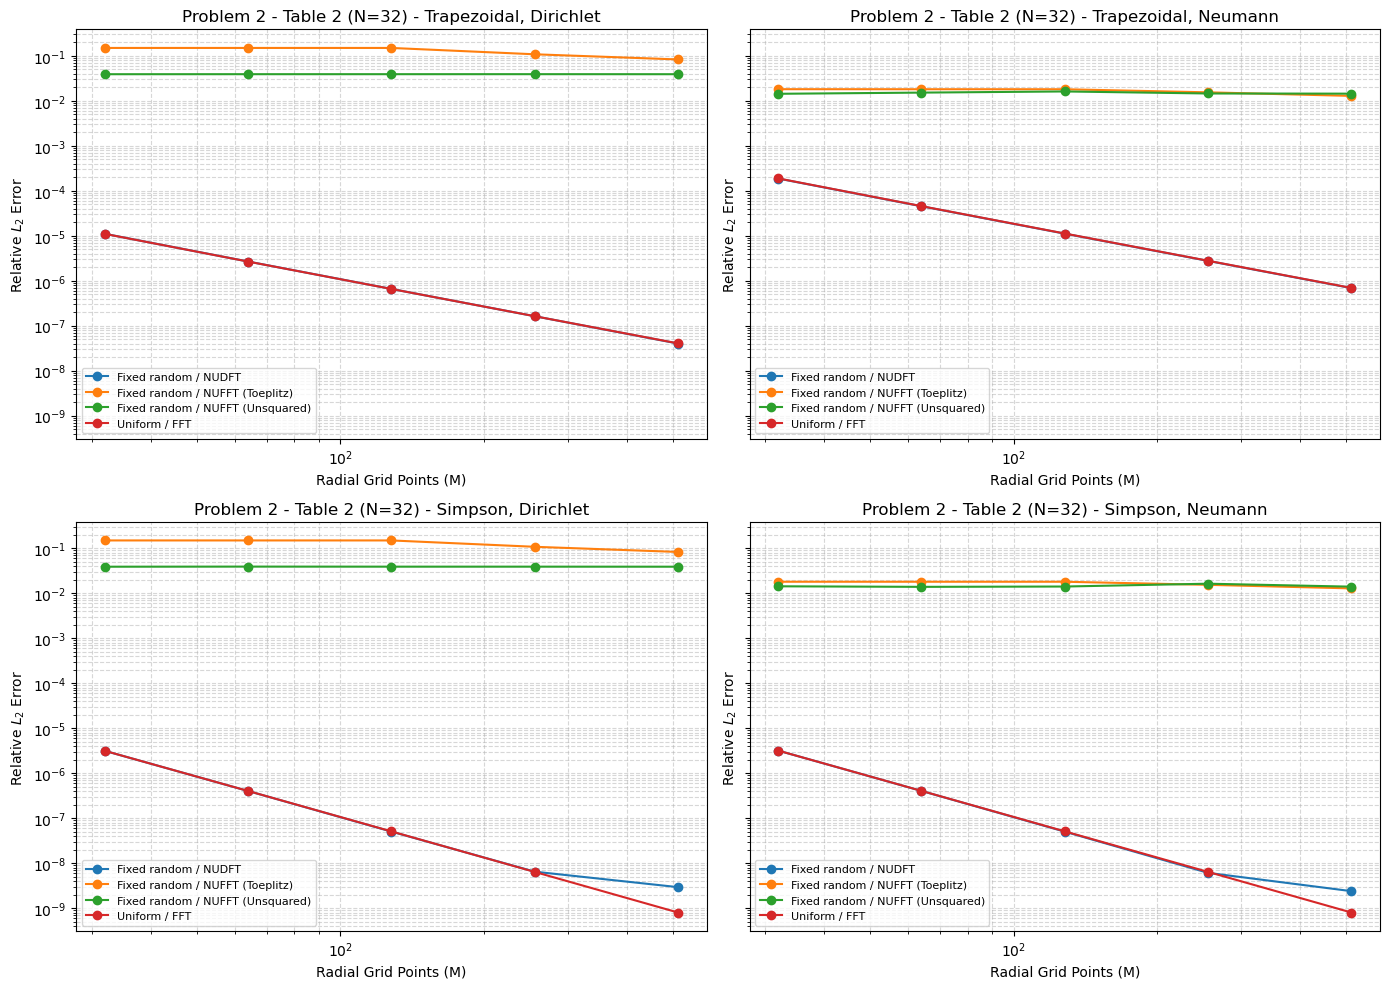

Problem 2 - Table 1 -All errors should be same along rows, and relatively same along columns

Accuracy Comparison (Fixed M=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
N,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,8.48e-04,4.49e-04,1.49e-01,3.89e-02,2.40e-03,4.00e-05
64,1.10e-05,1.10e-05,1.10e-05,2.71e-02,1.08e-05,1.11e-05,1.16e-03,6.89e-04,3.96e-02,7.04e-02,1.27e-03,5.08e-04
128,1.10e-05,1.10e-05,1.10e-05,1.33e-01,1.16e-05,5.02e-02,1.00e-03,1.78e-04,1.23e-01,2.21e-01,6.59e-04,1.46e-04
256,1.10e-05,1.10e-05,1.10e-05,1.75e-01,3.34e-02,9.61e-02,1.00e-03,1.80e-04,1.27e-01,1.73e-01,6.93e-04,1.38e-05
512,1.10e-05,1.10e-05,1.10e-05,4.43e-02,1.29e-01,1.39e-02,1.01e-03,6.15e-05,1.99e-01,9.95e-01,2.87e-04,1.10e-05


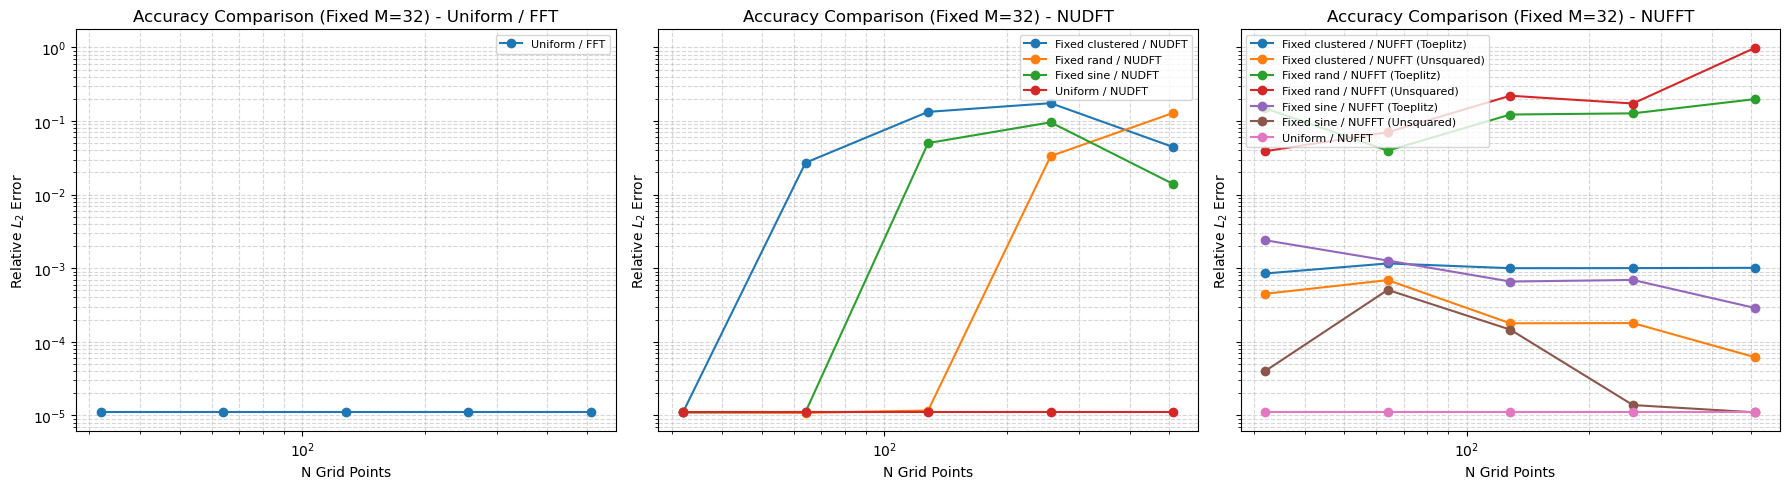

errors for diff meshes getting worse suggests nudft or nufft not accurate
Problem 2 - Table 2 -All errors should decrease along rows, and relatively same along columns

Accuracy Comparison (Fixed N=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
M,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,8.48e-04,4.49e-04,1.49e-01,3.89e-02,2.40e-03,4.00e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.67e-06,2.66e-06,8.22e-04,1.54e-04,1.49e-01,3.89e-02,2.36e-03,3.95e-05
128,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.56e-07,6.55e-07,8.12e-04,1.54e-04,1.49e-01,3.89e-02,2.34e-03,4.64e-05
256,1.62e-07,1.62e-07,1.62e-07,1.82e-07,1.62e-07,1.62e-07,8.07e-04,1.54e-04,1.08e-01,3.89e-02,2.33e-03,3.37e-05
512,4.04e-08,4.04e-08,4.04e-08,9.25e-08,4.01e-08,4.05e-08,8.04e-04,1.54e-04,8.28e-02,3.89e-02,2.33e-03,3.35e-05


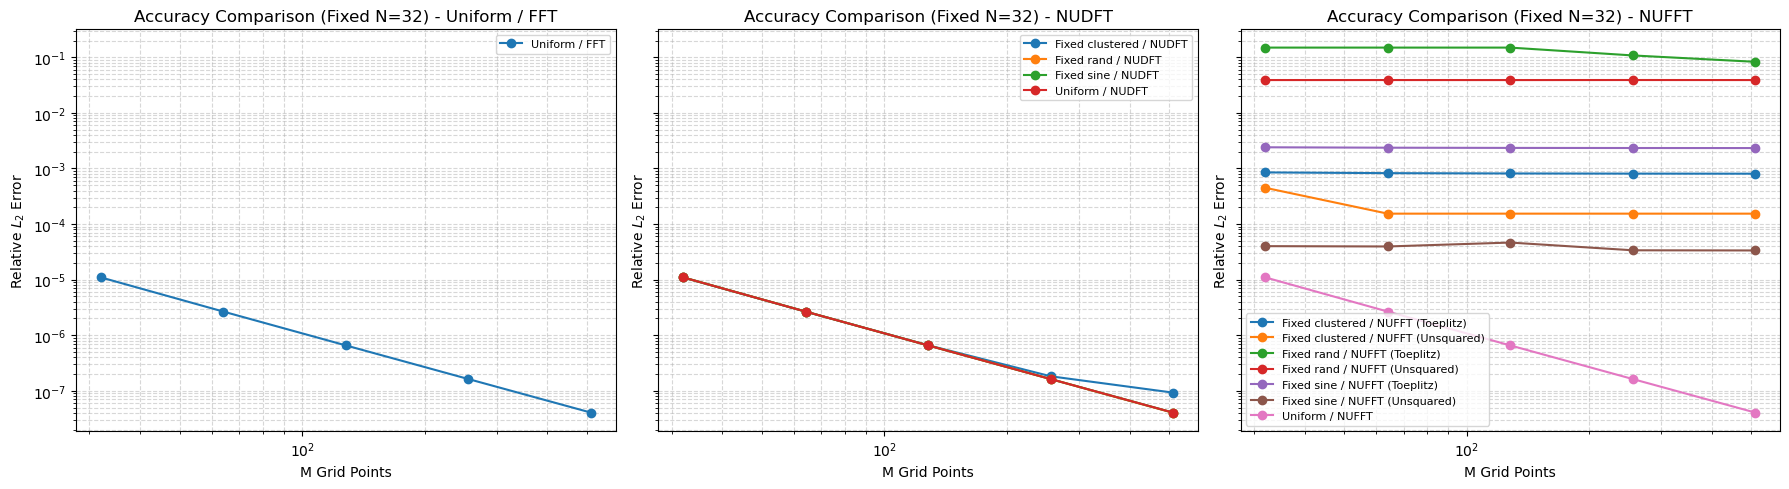

errors for diff meshes getting worse suggests nudft or nufft not accurate


In [4]:
print("--- ACCURACY SECTION ---")


print("Problem 2 - Table 1 - errors should be the same for rows, and decrease along columns. uniform, nudft, and nufft should be same")
render_accuracy(df_p2_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 2 - Table 1")
plot_accuracy_table1(df_p2_t1, title_prefix="Problem 2 - Table 1")

print("Problem 2 - Table 2 - errors should decrease along rows")
render_table2_accuracy(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")
plot_accuracy_table2(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")

print("Problem 2 - Table 1 -All errors should be same along rows, and relatively same along columns")
render_accuracy(df_cN, index_col="N", columns_col="label", title_prefix="Accuracy Comparison (Fixed M=32)")
plot_accuracy_comparison(df_cN, index_col="N", title_prefix="Accuracy Comparison (Fixed M=32)")
print("errors for diff meshes getting worse suggests nudft or nufft not accurate")

print("Problem 2 - Table 2 -All errors should decrease along rows, and relatively same along columns")
render_accuracy(df_cM, index_col="M", columns_col="label", title_prefix="Accuracy Comparison (Fixed N=32)")
plot_accuracy_comparison(df_cM, index_col="M", title_prefix="Accuracy Comparison (Fixed N=32)")
print("errors for diff meshes getting worse suggests nudft or nufft not accurate")


# Runtimes

--- RUNTIME SECTION ---
Problem 2 - Table 1 Runtimes (Stratified Rand)

Problem 2 - Table 1 Runtime (s)


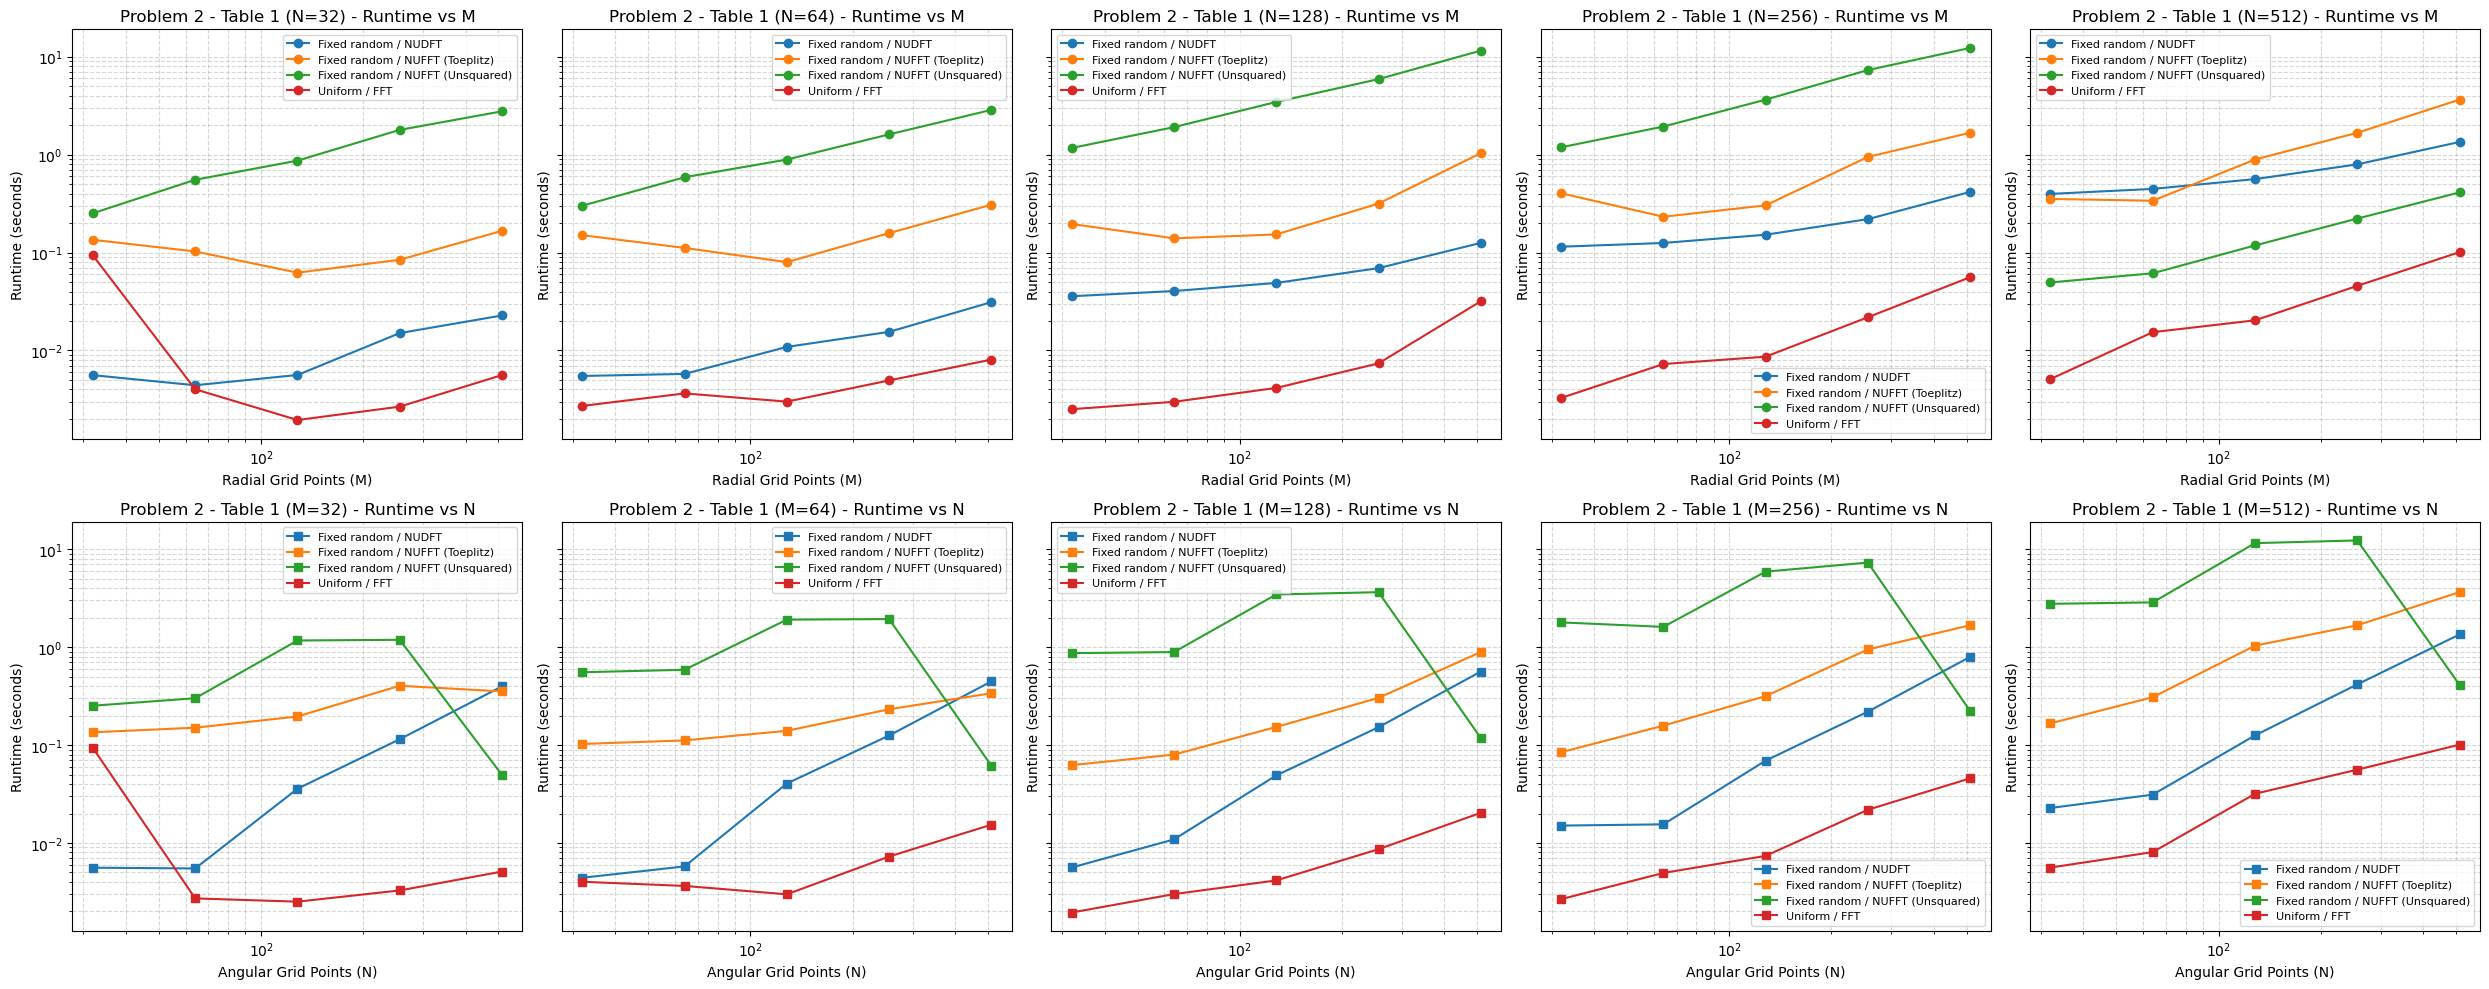

Problem 2 - Table 2 Runtimes (Stratified Rand)

Problem 2 - Table 2 (N=32) Runtime (s)


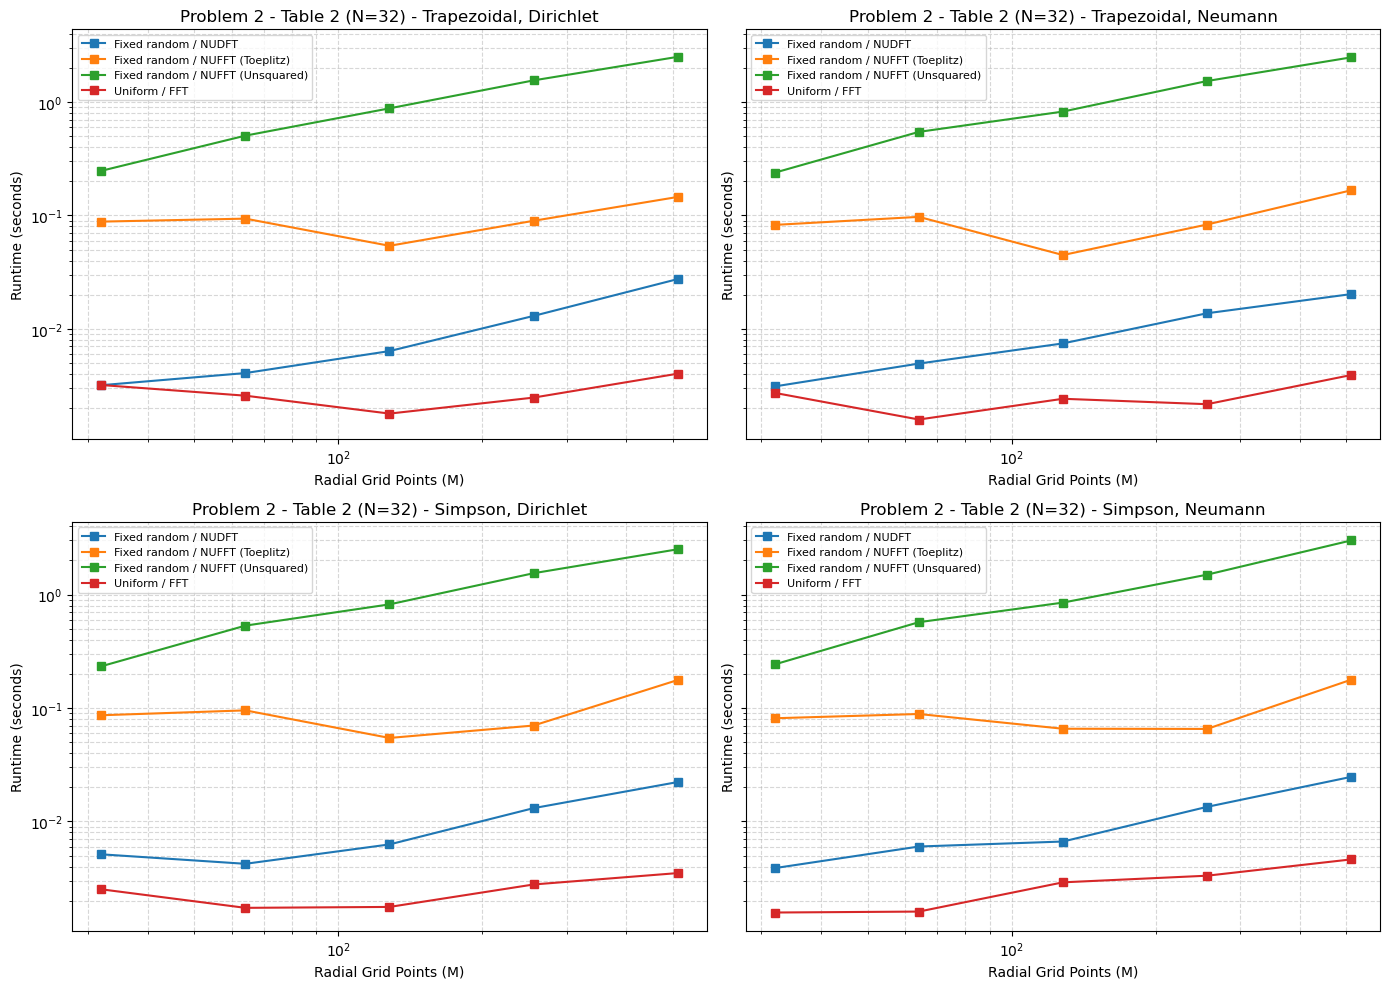

Accuracy Comparison (Fixed M=32) Runtimes

Accuracy Comparison (Fixed M=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
N,,,,,,,,,,,,
32,0.0035,0.0045,0.0165,0.0029,0.0027,0.0051,0.0884,0.0963,0.0913,0.3028,0.0903,0.2622
64,0.0018,0.0032,0.0151,0.0042,0.0042,0.0069,0.0949,0.1503,0.1162,0.2870,0.1170,0.1450
128,0.0017,0.0328,0.0321,0.0325,0.0342,0.0489,0.1078,1.1779,0.1630,1.2399,0.1419,0.4291
256,0.0033,0.1080,0.0331,0.1045,0.1088,0.1634,0.1197,1.1262,0.1753,1.4638,0.1737,0.2595
512,0.0073,0.3771,0.0368,0.3890,0.4448,0.3684,0.1928,1.1951,0.2391,0.0997,0.2346,0.1970


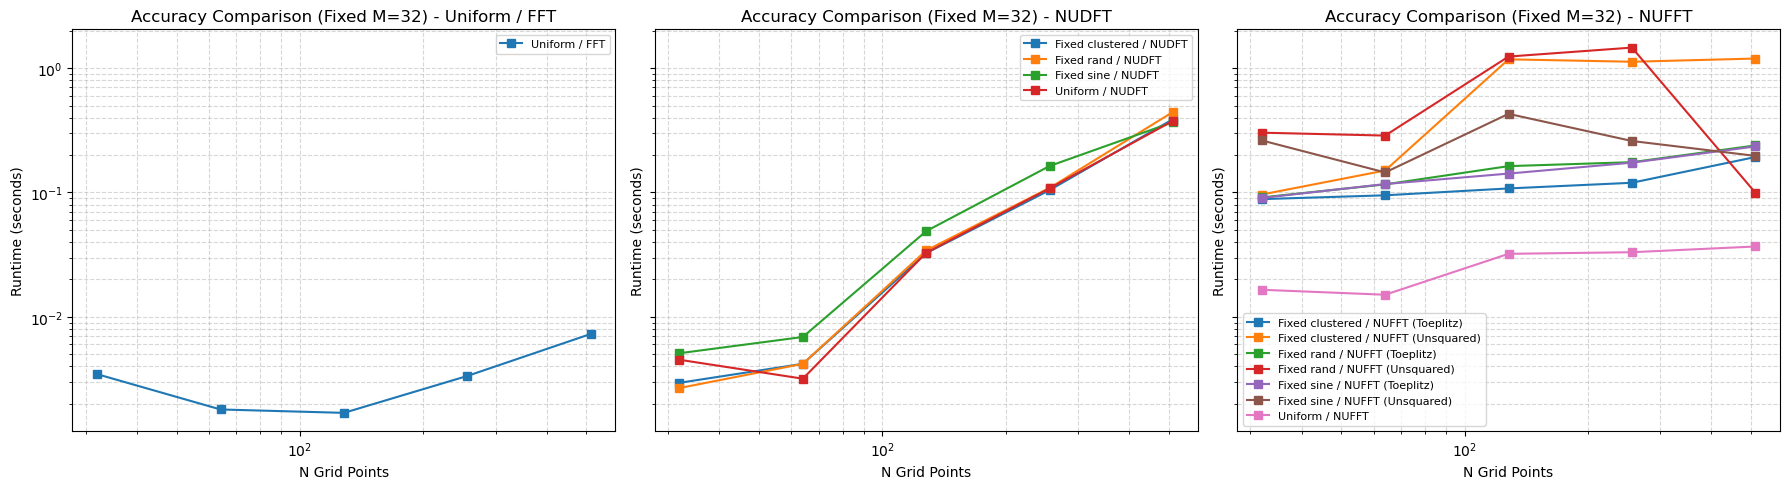

Accuracy Comparison (Fixed N=32) Runtimes

Accuracy Comparison (Fixed N=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT (Toeplitz),Fixed clustered / NUFFT (Unsquared),Fixed rand / NUFFT (Toeplitz),Fixed rand / NUFFT (Unsquared),Fixed sine / NUFFT (Toeplitz),Fixed sine / NUFFT (Unsquared)
M,,,,,,,,,,,,
32,0.0016,0.0052,0.0126,0.0043,0.0031,0.0043,0.0809,0.0945,0.0856,0.2758,0.0832,0.2373
64,0.0026,0.0054,0.0194,0.0034,0.0032,0.0040,0.0869,0.4877,0.0830,0.5466,0.0814,0.4835
128,0.0030,0.0086,0.0215,0.0063,0.0050,0.0064,0.0497,0.7770,0.0558,0.8029,0.0536,0.7763
256,0.0023,0.0135,0.0323,0.0111,0.0126,0.0122,0.0810,1.3556,0.0707,1.3272,0.0709,1.6374
512,0.0054,0.0207,0.0558,0.0209,0.0204,0.0289,0.1515,2.6434,0.1562,2.3806,0.1513,2.4520


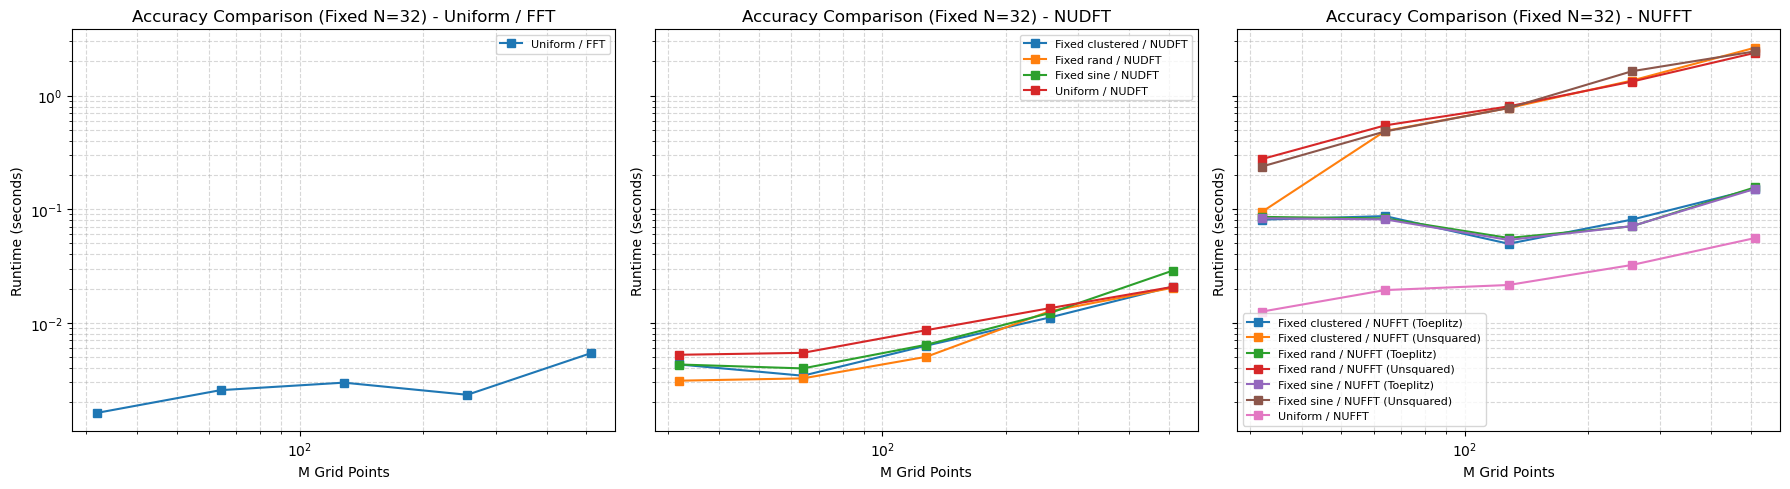

In [5]:
print("--- RUNTIME SECTION ---")


print("Problem 2 - Table 1 Runtimes (Stratified Rand)")
render_runtime(df_p2_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 2 - Table 1")
plot_runtime_table1(df_p2_t1, title_prefix="Problem 2 - Table 1")

print("Problem 2 - Table 2 Runtimes (Stratified Rand)")
render_table2_runtime(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")
plot_runtime_table2(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")

print("Accuracy Comparison (Fixed M=32) Runtimes")
render_runtime(df_cN, index_col="N", columns_col="label", title_prefix="Accuracy Comparison (Fixed M=32)")
plot_runtime_comparison(df_cN, index_col="N", title_prefix="Accuracy Comparison (Fixed M=32)")

print("Accuracy Comparison (Fixed N=32) Runtimes")
render_runtime(df_cM, index_col="M", columns_col="label", title_prefix="Accuracy Comparison (Fixed N=32)")
plot_runtime_comparison(df_cM, index_col="M", title_prefix="Accuracy Comparison (Fixed N=32)")
